# Классификация овощей с помощью свёрточных нейронных сетей.

**Цели и задачи**

Цель: изучить процесс классификации объектов с помощью свёрточной нейронной сети на примере данных с kaggle.

Задачи:

* Загрузить и предобработать данные.

* Разбить данные на обучающую, проверочную и тестовую выборки.

* Определить архитектуру свёрточной нейронной сети (использовать предобученную архитектуру и архитектуру "с нуля").

* Обучить модели на обучающей выборке.

* Оценить качество моделей на проверочной выборке.

* Подобрать оптимальные гиперпараметры моделей на основе результатов на проверочной выборке.

* Протестировать модели на тестовой выборке.

* Оценить качество моделей на основе метрик.

* Построить графики, чтобы проанализировать процесс обучения и оценки качества моделей на обучающей, проверочной выборках.

## 1) Загрузка данных

In [ ]:
import numpy as np
import pandas as pd
import os

FOLDERNAME = '/kaggle/input/vegetable-image-dataset/Vegetable Images/'
%cd /kaggle/input/vegetable-image-dataset/Vegetable Images/


train_path = '/kaggle/input/vegetable-image-dataset/Vegetable Images/train'
test_path = '/kaggle/input/vegetable-image-dataset/Vegetable Images/test'
val_path = '/kaggle/input/vegetable-image-dataset/Vegetable Images/validation'

/kaggle/input/vegetable-image-dataset/Vegetable Images


In [2]:
from torchvision import datasets, transforms
from torchvision.transforms import v2
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm
from PIL import Image
import os

import matplotlib.pyplot as plt
from tqdm.notebook import trange, tqdm
import seaborn as sns
import torch

In [3]:
import random

seed = 42
random.seed(seed)
torch.manual_seed(seed)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


## 2) Предобработка

Можно заметить, что не все изображения одного размера (учтём это при создании загрузчика)

In [4]:
incorrect_size_images = []

dataset = datasets.ImageFolder(root=train_path)

for img_path, _ in dataset.imgs:  # dataset.imgs gives (image_path, label)
    with Image.open(img_path) as img:
        if img.size != (224, 224):
            incorrect_size_images.append(img_path)

print("Images that are NOT 224x224:")
for img_path in incorrect_size_images:
    print(img_path)


Images that are NOT 224x224:
/kaggle/input/vegetable-image-dataset/Vegetable Images/train/Bitter_Gourd/0430.jpg
/kaggle/input/vegetable-image-dataset/Vegetable Images/train/Bitter_Gourd/0526.jpg
/kaggle/input/vegetable-image-dataset/Vegetable Images/train/Bitter_Gourd/0609.jpg
/kaggle/input/vegetable-image-dataset/Vegetable Images/train/Papaya/0126.jpg
/kaggle/input/vegetable-image-dataset/Vegetable Images/train/Papaya/0176.jpg
/kaggle/input/vegetable-image-dataset/Vegetable Images/train/Papaya/0741.jpg


Посмотрим на примеры объектов каждого класса

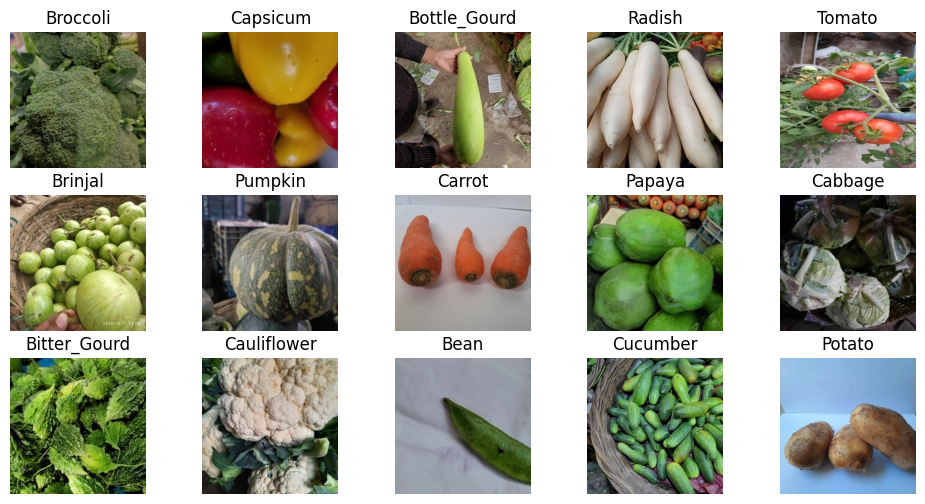

In [5]:
classes = os.listdir(train_path)

plt.figure(figsize=(12, 6))
for i, class_name in enumerate(classes):
    class_dir = os.path.join(train_path, class_name)
    imgs = os.listdir(class_dir)
    img_path = os.path.join(class_dir, imgs[0])

    img = Image.open(img_path)
    plt.subplot(3, 5, i + 1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

Теперь рассчитаем среднее и дисперсию для дальнейшей нормализации

In [ ]:
transform = v2.Compose([
    v2.ToImage(),
    v2.Resize(size=(224, 224), antialias=True),
    v2.ToDtype(torch.float32, scale=True),
])

dataset = datasets.ImageFolder(root=train_path, transform=transform)
loader = DataLoader(dataset, batch_size=64, shuffle=False)

# Compute mean & std
mean = torch.zeros(3)
std = torch.zeros(3)
num_samples = 0

for i, data in enumerate(tqdm(loader)):
    images = data[0]
    batch_samples = images.size(0)
    num_samples += batch_samples
    mean += images.mean(dim=[0, 2, 3]) * batch_samples
    std += images.std(dim=[0, 2, 3]) * batch_samples

mean /= num_samples
std /= num_samples

print(f"Dataset Mean: {mean.tolist()}")
print(f"Dataset Std: {std.tolist()}")

Здесь создаём загрузчики для каждого набора данных

In [101]:
train_transform = v2.Compose([
    v2.Resize(size=(224, 224), antialias=True),
    v2.RandomHorizontalFlip(p=0.5),  # Flip images horizontally with 50% chance
    v2.RandomRotation(degrees=15),  # Rotate images by +-15 degrees
    v2.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),  # Random color changes
    v2.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1), shear=5),  # Small affine transformations
    v2.ToImage(),  # Ensures input is a tensor
    v2.ToDtype(torch.float32, scale=True),  # Converts to float32 and scales [0,255] → [0,1]
    v2.Normalize(mean=mean, std=std)  # Normalize to [-1,1]
])

test_val_transform = v2.Compose([
    v2.Resize(size=(224, 224), antialias=True),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=mean, std=std)
])

train_dataset = datasets.ImageFolder(root=train_path, transform=train_transform)
test_dataset = datasets.ImageFolder(root=test_path, transform=test_val_transform)
val_dataset = datasets.ImageFolder(root=val_path, transform=test_val_transform)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True)
print(f"Classes: {train_dataset.classes}")

# Check a sample batch
data_iter = iter(train_loader)
images, labels = next(data_iter)
print(f"Batch image shape: {images.shape}")
print(f"Batch label shape: {labels.shape}")

Classes: ['Bean', 'Bitter_Gourd', 'Bottle_Gourd', 'Brinjal', 'Broccoli', 'Cabbage', 'Capsicum', 'Carrot', 'Cauliflower', 'Cucumber', 'Papaya', 'Potato', 'Pumpkin', 'Radish', 'Tomato']
Batch image shape: torch.Size([32, 3, 224, 224])
Batch label shape: torch.Size([32])


Вспомогательная функция для вывода изображений

In [99]:
un_norm = v2.Compose([ transforms.Normalize(mean = [ 0., 0., 0. ], 
                                             std = list(1 / std.numpy())),
                        transforms.Normalize(mean = list(-mean.numpy()), 
                                             std = [ 1., 1., 1. ]),
                        ])

## 3) Архитектура и обучение

Сначала создадим свою архитектуру свёрточной НС с нуля. За основу я взял AlexNet

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

class VegNet(nn.Module):
    def __init__(self, num_classes: int = 15, dropout: float = 0.5) -> None:
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=7, stride=3),# (224-7)/3+1 = 73
            nn.MaxPool2d(kernel_size=3, stride=2), # (73-3)/2+1 = 36
            nn.ReLU(inplace=True),
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1), # (36-3+2)+1 = 36
            nn.MaxPool2d(kernel_size=3, stride=2), # (36-3)/2+1 = 17
            nn.ReLU(inplace=True),
            
            nn.Conv2d(64, 96, kernel_size=3, padding=1), # 26-3+2+1 = 17
            nn.ReLU(inplace=True),
            nn.Conv2d(96, 96, kernel_size=3, padding=1), # 26-3+2+1 = 17
            nn.ReLU(inplace=True),
            nn.Conv2d(96, 64, kernel_size=3, padding=1), # 26-3+2+1 = 17
            nn.MaxPool2d(kernel_size=3, stride=2), # (17-3)/2+1 = 8
            nn.ReLU(inplace=True),
        )
        
        self.classifier = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(64 * 8 * 8, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout),
            nn.Linear(512, 512),
            nn.ReLU(inplace=True),
            nn.Linear(512, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x
        

Создадим функции для обучения и валидации

In [12]:
def train_loop(loader: DataLoader, model: nn.Module, criterion: nn.Module, optim: optim.Optimizer) -> float:
    num_batches = len(loader)

    train_loss = 0

    for i, batch in tqdm(enumerate(loader),
                        total=num_batches,
                        desc=f"Training on epoch {epoch}"):
        imgs, labels = batch
        
        model.train()
        pred = model(imgs.to(device))
        loss = criterion(pred, labels.to(device))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= num_batches
    print(f"Train loss: {train_loss:>8f}")

    return train_loss

def val_loop(loader: DataLoader, model: nn.Module, criterion: nn.Module) -> float:
    size = len(loader.dataset)
    num_batches = len(loader)

    val_loss, correct = 0, 0

    model.eval()
    with torch.no_grad():
        for i, batch in tqdm(enumerate(loader),
                        total=num_batches,
                        desc=f"Validating on epoch {epoch}"):
            imgs, labels = batch
            pred = model(imgs.to(device))
            loss = criterion(pred, labels.to(device))

            val_loss += loss.item()
            correct += (
                (pred.argmax(1) == labels.to(device)).type(torch.float).sum().item()
            )

    val_loss /= num_batches
    correct /= size
    print(f"Test loss: {val_loss:>8f}, val accuracy: {(100*correct):>0.1f}% \n")

    return val_loss

In [ ]:
model = VegNet(15).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# for plotting
loss_history = {"train": [], "val": []}

epochs = 20
for epoch in trange(epochs, desc="Epochs"):
    train_loss = train_loop(train_loader, model, criterion, optimizer)
    val_loss = val_loop(val_loader, model, criterion)

    loss_history["train"].append(train_loss)
    loss_history["val"].append(val_loss)
    
print("Done!")

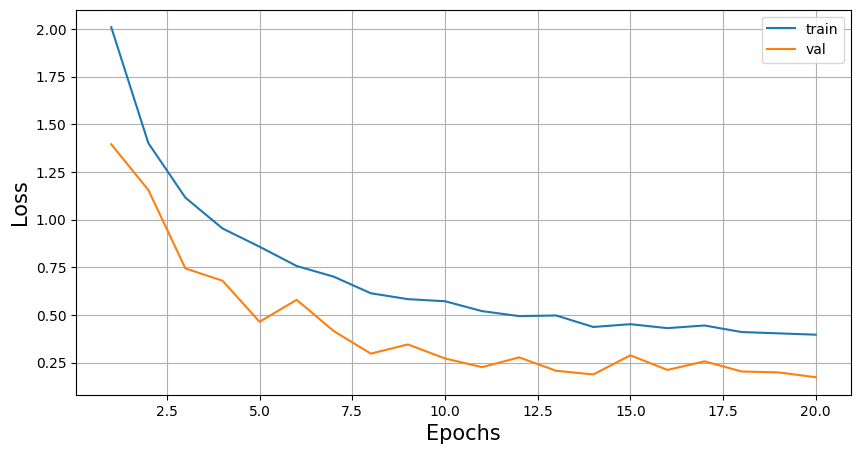

In [14]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), loss_history["train"], label="train")
plt.plot(range(1, epochs + 1), loss_history["val"], label="val")
plt.xlabel("Epochs", fontsize=15)
plt.ylabel("Loss", fontsize=15)
plt.legend()
plt.grid()
plt.show()

In [27]:
def calculate_accuracy(loader: DataLoader, model: nn.Module):
    correct = 0
    total = 0

    model.eval()
    with torch.no_grad():
        for data in loader:
            images, labels = data
            outputs = model(images.to(device))
            _, predicted = torch.max(outputs, 1)
            total += labels.to(device).size(0)
            correct += (predicted == labels.to(device)).sum().item()
    
    print(f'Accuracy of the {model.__class__.__name__} on the test images: {100 * correct / total} %')

In [37]:
def calculate_classes_accuracy(loader: DataLoader, model: nn.Module):
    correct_pred = {classname: 0 for classname in classes}
    total_pred = {classname: 0 for classname in classes}
    
    with torch.no_grad():
        for data in loader:
            images, labels = data
            outputs = model(images.to(device))
            _, predictions = torch.max(outputs, 1)
            # collect the correct predictions for each class
            for label, prediction in zip(labels.to(device), predictions):
                if label == prediction:
                    correct_pred[classes[label]] += 1
                total_pred[classes[label]] += 1
    
    
    for classname, correct_count in correct_pred.items():
        accuracy = 100 * float(correct_count) / total_pred[classname]
        print(f'Accuracy for class: {classname:5s} is {accuracy:.1f} %')

In [102]:
calculate_accuracy(test_loader, model)

Accuracy of the VegNet on the test images: 94.2 %


In [103]:
calculate_classes_accuracy(test_loader, model)

Accuracy for class: Bean  is 83.0 %
Accuracy for class: Bitter_Gourd is 94.5 %
Accuracy for class: Bottle_Gourd is 97.0 %
Accuracy for class: Brinjal is 91.5 %
Accuracy for class: Broccoli is 97.5 %
Accuracy for class: Cabbage is 83.5 %
Accuracy for class: Capsicum is 96.5 %
Accuracy for class: Carrot is 99.5 %
Accuracy for class: Cauliflower is 89.0 %
Accuracy for class: Cucumber is 95.0 %
Accuracy for class: Papaya is 97.5 %
Accuracy for class: Potato is 99.5 %
Accuracy for class: Pumpkin is 93.0 %
Accuracy for class: Radish is 100.0 %
Accuracy for class: Tomato is 96.0 %


Теперь будем использовать transfer learning. Я взял предобученную ResNet50 и разморозил последние два слоя

In [29]:
from torchvision.models import resnet50, ResNet50_Weights

resnet_model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)

In [31]:
from itertools import chain

layers_to_unfreeze = 2

# Выключаем подсчет градиентов для всех слоёв
for param in resnet_model.parameters():
    param.requires_grad = False

# Разморозим часть последних слоёв
for param in resnet_model.layer4.parameters():
    param.requires_grad = True

for param in resnet_model.layer3[-layers_to_unfreeze:].parameters():
    param.requires_grad = True

# num_features -- это размерность вектора фич, поступающего на вход FC-слою
num_features = resnet_model.fc.in_features
# Заменяем Fully-Connected слой на наш линейный классификатор
resnet_model.fc = nn.Linear(num_features, 15)

optimizer = torch.optim.Adam(
    chain(
        list(resnet_model.layer3[-layers_to_unfreeze:].parameters()),
        list(resnet_model.layer4.parameters()),
        resnet_model.fc.parameters()
    ),
    lr=1e-4, 
)

resnet_model = resnet_model.to(device)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(resnet_model.parameters(), lr=0.001)

loss_history = {"train": [], "val": []}

epochs = 3
for epoch in trange(epochs, desc="Epochs"):
    train_loss = train_loop(train_loader, resnet_model, criterion, optimizer)
    val_loss = val_loop(val_loader, resnet_model, criterion)

    loss_history["train"].append(train_loss)
    loss_history["val"].append(val_loss)
    
print("Done!")

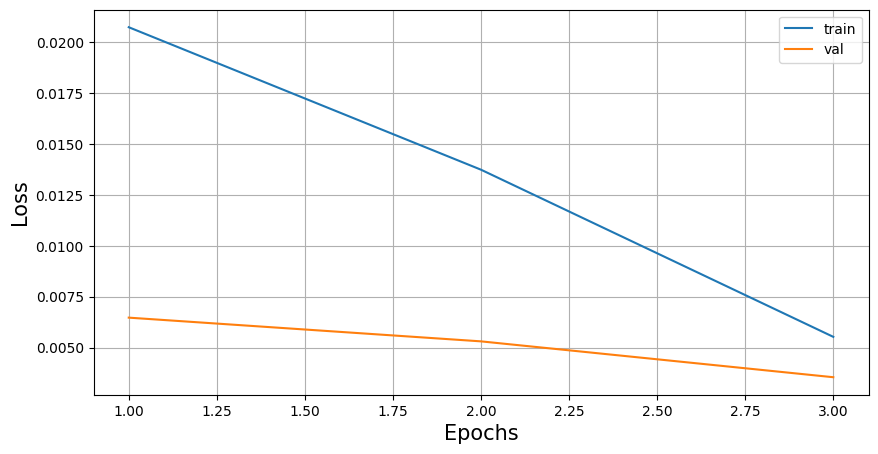

In [36]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), loss_history["train"], label="train")
plt.plot(range(1, epochs + 1), loss_history["val"], label="val")
plt.xlabel("Epochs", fontsize=15)
plt.ylabel("Loss", fontsize=15)
plt.legend()
plt.grid()
plt.show()

In [39]:
calculate_accuracy(test_loader, resnet_model)

Accuracy of the ResNet on the test images: 99.76666666666667 %


In [104]:
calculate_classes_accuracy(test_loader, resnet_model)

Accuracy for class: Bean  is 100.0 %
Accuracy for class: Bitter_Gourd is 97.0 %
Accuracy for class: Bottle_Gourd is 100.0 %
Accuracy for class: Brinjal is 100.0 %
Accuracy for class: Broccoli is 100.0 %
Accuracy for class: Cabbage is 100.0 %
Accuracy for class: Capsicum is 100.0 %
Accuracy for class: Carrot is 100.0 %
Accuracy for class: Cauliflower is 99.5 %
Accuracy for class: Cucumber is 100.0 %
Accuracy for class: Papaya is 100.0 %
Accuracy for class: Potato is 100.0 %
Accuracy for class: Pumpkin is 100.0 %
Accuracy for class: Radish is 100.0 %
Accuracy for class: Tomato is 100.0 %


## 4) Предсказания полученных моделей

In [118]:
imgs, labels = next(iter(test_loader))

Предсказания VegNet

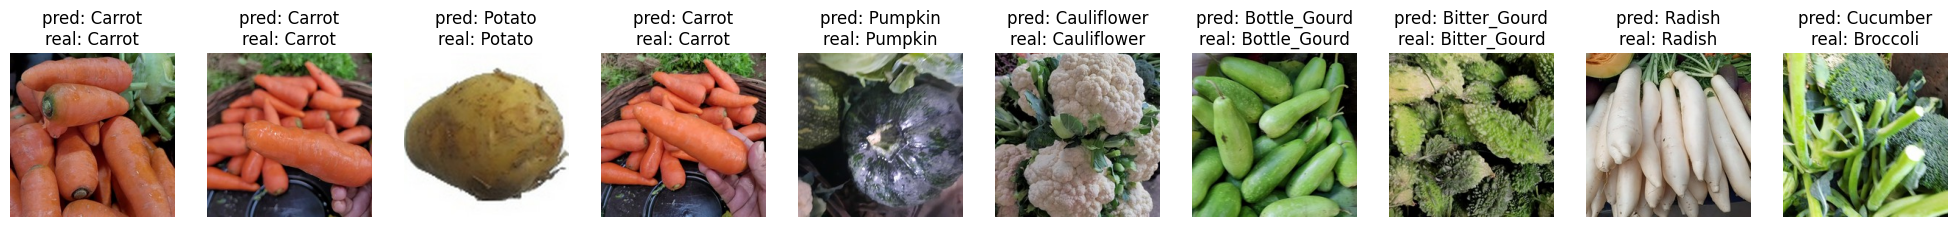

In [119]:
outputs = model(imgs.to(device))

_, pred = torch.max(outputs, 1)

plt.figure(figsize=(25, 25))
for i in range(10):
    img = un_norm(imgs[i])

    plt.subplot(1, 10, i + 1)
    plt.title(
        f"pred: {classes[pred[i]]}\nreal: {classes[labels[i].numpy()]}"
    )
    plt.axis("off")
    plt.imshow(img.permute(1,2,0).numpy())

Предсказания ResNet50

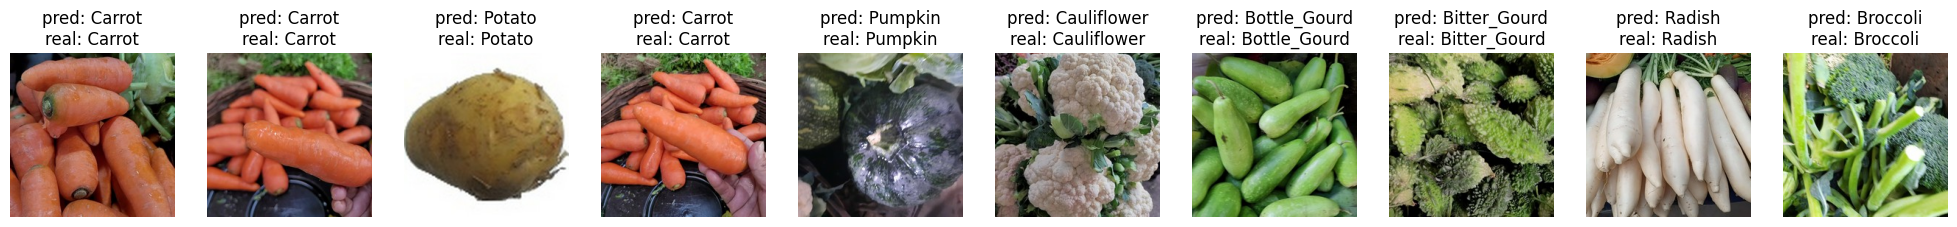

In [ ]:
outputs = resnet_model(imgs.to(device))

_, pred = torch.max(outputs, 1)

plt.figure(figsize=(25, 25))
for i in range(10):
    img = un_norm(imgs[i])

    plt.subplot(1, 10, i + 1)
    plt.title(
        f"pred: {classes[pred[i]]}\nreal: {classes[labels[i].numpy()]}"
    )
    plt.axis("off")
    plt.imshow(img.permute(1,2,0).numpy())